# House Price Prediction — Data Cleaning, EDA & Modeling

Dataset: **House Price** by Juhi Bhojani (Kaggle) — `data/house_prices.csv`, real
property listings scraped from Indian real-estate portals.

This notebook:
1. Loads and inspects the raw data
2. Explores it visually (EDA)
3. Cleans it and engineers model-ready features
4. Builds a `scikit-learn` `Pipeline` + `ColumnTransformer`
5. Trains and compares 3 regression models
6. Evaluates the winner on the held-out test set
7. Exports the fitted pipeline as `house_price.pkl` for the FastAPI backend


## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 30)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)  # % missing per column

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**How many rows?** ~187,500 property listings.

**Numeric vs text columns.** Only `Index`, `Price (in rupees)`, `Dimensions` and
`Plot Area` are stored as numbers by pandas — but that is misleading: `Dimensions`
and `Plot Area` are 100% empty (so effectively useless), and several columns that
*should* be numeric (`Amount(in rupees)`, `Carpet Area`, `Super Area`, `Floor`,
`Bathroom`, `Balcony`, `Car Parking`) are stored as free-text strings like
`"42 Lac"`, `"1200 sqft"`, `"3 out of 10"` or `"1 Open"`. Cleaning these into real
numbers is the main job of section 2.3.

**Most missing values.** `Plot Area` and `Dimensions` are 100% missing, followed by
`Society`, `Super Area`, `Car Parking`, `overlooking`, `Carpet Area`, `facing` and
`Ownership` (35–58% missing). `Price (in rupees)` (a pre-parsed price column) is
~9% missing, which is why we parse `Amount(in rupees)` ourselves instead of relying
on it.

## 2.2 Exploratory Data Analysis (EDA)

Before cleaning we look at price as reported (`Price (in rupees)`, dropping the ~9%
missing rows) to get a first feel for the distribution, location effects and
categorical relationships.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
eda_df = df.dropna(subset=["Price (in rupees)"]).copy()

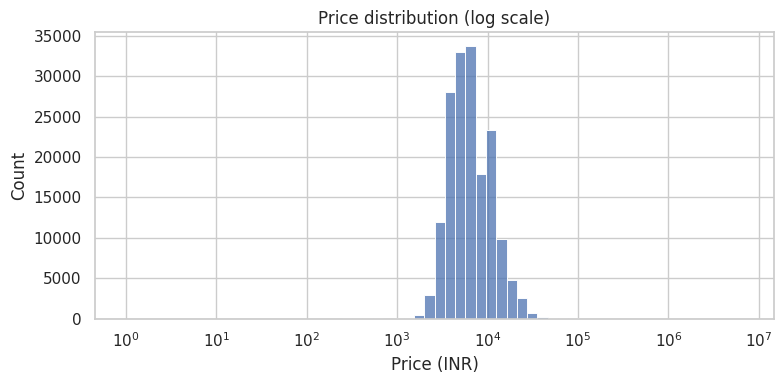

In [7]:
# Plot 1 — distribution of price (log scale)
plt.figure(figsize=(8, 4))
sns.histplot(eda_df["Price (in rupees)"], log_scale=True, bins=60)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.tight_layout()
plt.show()

**Comment:** raw price is extremely right-skewed — most listings sit between
₹20 Lac and ₹2 Cr, but a long tail of luxury properties stretches into the tens of
crores. This is why we will train on `log1p(price)` rather than raw price.

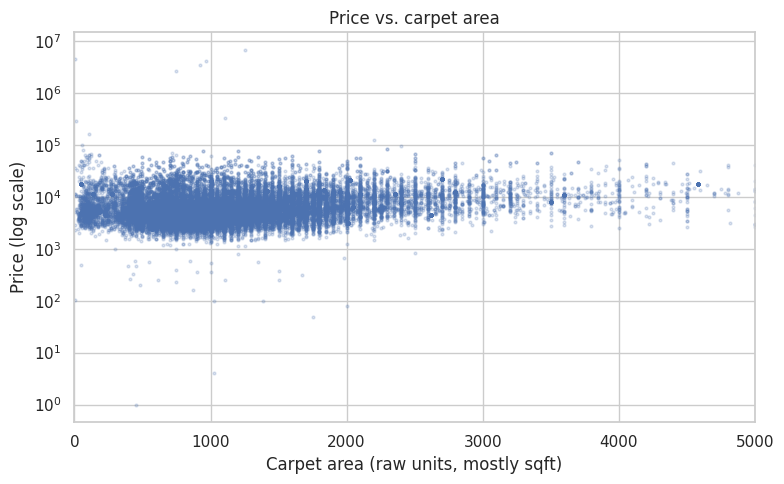

In [8]:
# Plot 2 — price vs carpet area
area_num = (
    eda_df["Carpet Area"].str.extract(r"([\d,.]+)")[0].str.replace(",", "", regex=False).astype(float)
)
plt.figure(figsize=(8, 5))
plt.scatter(area_num, eda_df["Price (in rupees)"], s=4, alpha=0.2)
plt.yscale("log")
plt.xlim(0, 5000)
plt.xlabel("Carpet area (raw units, mostly sqft)")
plt.ylabel("Price (log scale)")
plt.title("Price vs. carpet area")
plt.tight_layout()
plt.show()

**Comment:** price rises with carpet area as expected, but the cloud is wide —
location and property quality also matter a lot, and there is visible noise from
mixed area units (sqft/sqm/sqyrd) that we will normalise in cleaning.

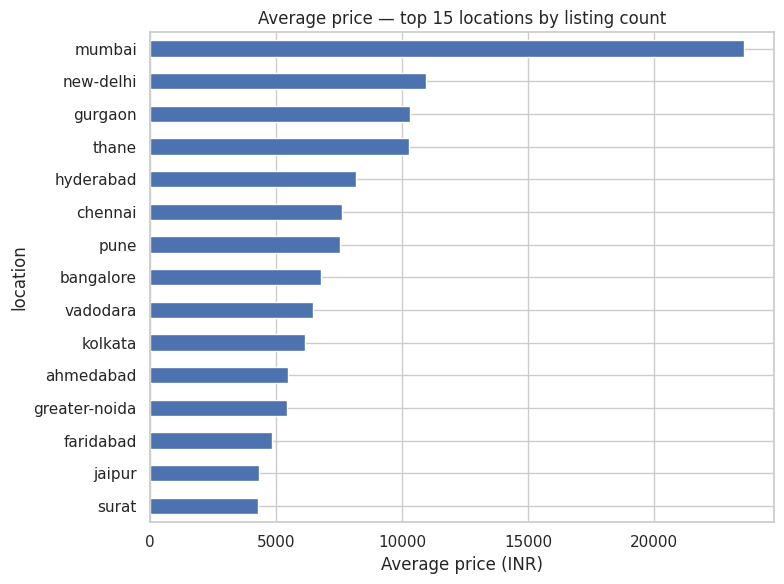

In [9]:
# Plot 3 — average price by top-15 locations
top15 = eda_df["location"].value_counts().nlargest(15).index
avg_by_loc = (
    eda_df[eda_df["location"].isin(top15)].groupby("location")["Price (in rupees)"].mean().sort_values()
)
plt.figure(figsize=(8, 6))
avg_by_loc.plot(kind="barh")
plt.xlabel("Average price (INR)")
plt.title("Average price — top 15 locations by listing count")
plt.tight_layout()
plt.show()

**Comment:** average price varies enormously by city — metro hubs like Mumbai
and Gurgaon sit far above tier-2 cities like Nagpur or Lucknow, confirming
`location` is an important predictive feature.

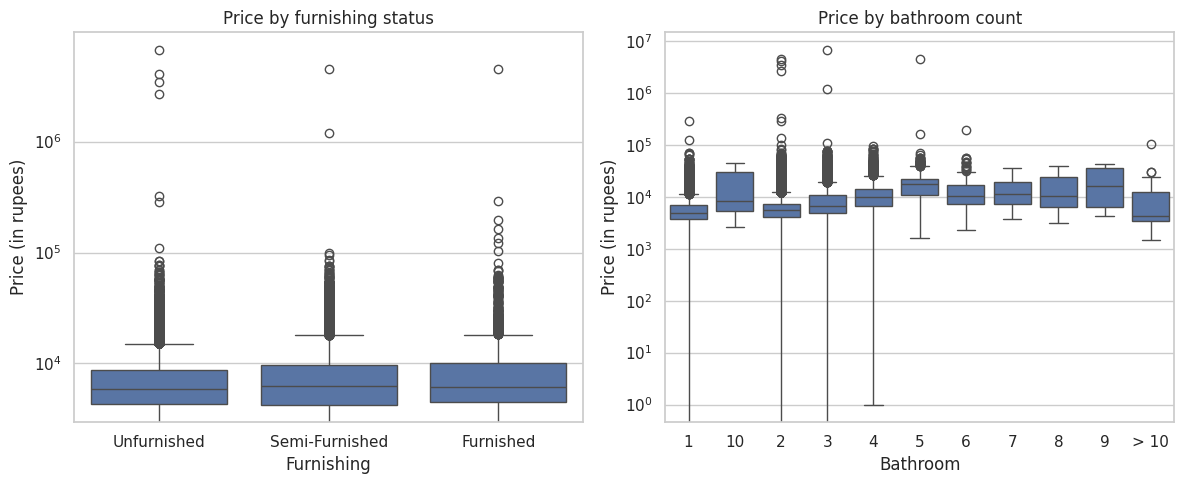

In [10]:
# Plot 4 — price by furnishing status and by bathroom count
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=eda_df, x="Furnishing", y="Price (in rupees)", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")

bath_order = sorted(eda_df["Bathroom"].dropna().unique(), key=lambda v: (v == "> 10", v))
sns.boxplot(data=eda_df[eda_df["Bathroom"].notna()], x="Bathroom", y="Price (in rupees)",
            order=bath_order, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by bathroom count")
plt.tight_layout()
plt.show()

**Comment:** furnished properties command a modest price premium over
unfurnished ones, and price increases steadily with the number of bathrooms — a
reasonable proxy for overall property size/quality.

## 2.3 Cleaning & Feature Engineering

This dataset is messy on purpose. We work through each problem listed in the
project guide.

### 2.3.1 Price is text (`Amount(in rupees)`)

In [11]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None


df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("Rows after price parsing:", df.shape[0])

Rows after price parsing: 177847


### 2.3.2 Areas are text (`Carpet Area` / `Super Area`)

In [12]:
import re

def parse_area(x):
    """Extract a number and normalise the unit to square feet."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    m = re.match(r"([\d,.]+)\s*([a-z]+)", x)
    if not m:
        return None
    try:
        num = float(m.group(1).replace(",", ""))
    except ValueError:
        return None
    unit = m.group(2)
    if unit == "sqft":
        return num
    if unit == "sqm":
        return num * 10.764
    if unit == "sqyrd":
        return num * 9.0
    return None  # rare units (marla, acre, kanal, ground, cent, bigha) -> treat as missing


df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)
# When Carpet Area is missing, fall back to Super Area rather than losing the row
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
print("carpet_area_sqft missing after fallback:", df["carpet_area_sqft"].isna().mean().round(4))

carpet_area_sqft missing after fallback: 0.0006


### 2.3.3 Floor (`"3 out of 10"`)

In [13]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split("out of")[0].strip()
    if first == "ground":
        return 0
    if first == "basement":
        return -1
    try:
        return float(first)
    except ValueError:
        return None


df["floor_num"] = df["Floor"].apply(parse_floor)
print("floor_num missing:", df["floor_num"].isna().mean().round(4))

floor_num missing: 0.041


### 2.3.4 Bathroom / Balcony — convert to numeric, impute

In [14]:
def parse_count(x):
    if not isinstance(x, str):
        return None
    x = x.strip()
    if x == "> 10":
        return 11.0
    try:
        return float(x)
    except ValueError:
        return None


df["bathroom"] = df["Bathroom"].apply(parse_count)
df["balcony"] = df["Balcony"].apply(parse_count)

df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(0)  # most listings without a balcony count truly have none

### 2.3.5 High-cardinality categorical — `location`

In [15]:
TOP_N = 30
top_locations = df["location"].value_counts().nlargest(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
print("Distinct location buckets:", df["location_grouped"].nunique())

Distinct location buckets: 31


### 2.3.6 Drop useless columns

In [16]:
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area",
                       "Society", "overlooking", "Car Parking", "Price (in rupees)",
                       "Carpet Area", "Super Area", "Floor", "Bathroom", "Balcony",
                       "location", "Status", "super_area_sqft"])
df = df.dropna(subset=["carpet_area_sqft"])  # need a usable area to model on
df.shape

(177732, 11)

### 2.3.7 Remove outliers (price-per-sqft below 1st / above 99th percentile)

In [17]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = df.shape[0]
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print(f"Dropped {before - df.shape[0]} outlier rows. Final shape: {df.shape}")

Dropped 3468 outlier rows. Final shape: (174264, 11)


## 2.4 Build a Pipeline & Train

We bundle preprocessing inside the exported model using a `ColumnTransformer` +
`Pipeline`, so the FastAPI backend only has to build a one-row `DataFrame` and call
`.predict()` — no manual encoding needed on the backend side.

Because price is heavily right-skewed (see 2.2), we train on `log1p(price)` and
invert with `expm1` at prediction time, as recommended in the guide.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = df[numeric_features + categorical_features]
y_raw = df["price_clean"]
y = np.log1p(y_raw)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(139411, 9) (34853, 9)


In [19]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
])

We train **3** models and compare them:

1. `LinearRegression` — simple baseline
2. `RandomForestRegressor` — trained on a random subsample of the training set to
   keep training time reasonable on a single CPU core (this notebook environment
   has no GPU/multi-core acceleration available)
3. `HistGradientBoostingRegressor` — a fast, histogram-based boosting model from
   `sklearn.ensemble`, trained on the full training set

In [20]:
import time

results = {}
fitted_models = {}

# ---- 1. Linear Regression (baseline) ----
t0 = time.time()
lin_model = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
lin_model.fit(X_train, y_train)
fit_time = time.time() - t0

pred = np.expm1(lin_model.predict(X_test))
actual = np.expm1(y_test)
results["LinearRegression"] = {
    "MAE": mean_absolute_error(actual, pred),
    "RMSE": root_mean_squared_error(actual, pred),
    "R2": r2_score(actual, pred),
    "fit_seconds": fit_time,
}
fitted_models["LinearRegression"] = lin_model
results["LinearRegression"]

{'MAE': 58703586196.74183,
 'RMSE': 8332446575745.566,
 'R2': -458039787915.88477,
 'fit_seconds': 1.3687093257904053}

In [21]:
# ---- 2. Random Forest (subsampled for speed) ----
rf_sample = X_train.sample(n=min(25000, len(X_train)), random_state=42)
y_rf_sample = y_train.loc[rf_sample.index]

t0 = time.time()
rf_model = Pipeline([("prep", preprocessor),
                      ("reg", RandomForestRegressor(n_estimators=60, max_depth=16,
                                                     n_jobs=-1, random_state=42))])
rf_model.fit(rf_sample, y_rf_sample)
fit_time = time.time() - t0

pred = np.expm1(rf_model.predict(X_test))
results["RandomForest"] = {
    "MAE": mean_absolute_error(actual, pred),
    "RMSE": root_mean_squared_error(actual, pred),
    "R2": r2_score(actual, pred),
    "fit_seconds": fit_time,
}
fitted_models["RandomForest"] = rf_model
results["RandomForest"]

{'MAE': 1209994.9890361738,
 'RMSE': 4257230.121431559,
 'R2': 0.880432711162457,
 'fit_seconds': 3.4317467212677}

In [22]:
# ---- 3. Hist Gradient Boosting (full training set) ----
t0 = time.time()
hgb_model = Pipeline([("prep", preprocessor),
                       ("reg", HistGradientBoostingRegressor(max_iter=300, max_depth=8,
                                                              learning_rate=0.08, random_state=42))])
hgb_model.fit(X_train, y_train)
fit_time = time.time() - t0

pred = np.expm1(hgb_model.predict(X_test))
results["HistGradientBoosting"] = {
    "MAE": mean_absolute_error(actual, pred),
    "RMSE": root_mean_squared_error(actual, pred),
    "R2": r2_score(actual, pred),
    "fit_seconds": fit_time,
}
fitted_models["HistGradientBoosting"] = hgb_model
results["HistGradientBoosting"]

{'MAE': 1350905.316420836,
 'RMSE': 3786719.0729244305,
 'R2': 0.9054014883652084,
 'fit_seconds': 10.07402753829956}

## 2.5 Evaluate

In [23]:
comparison = pd.DataFrame(results).T
comparison = comparison[["MAE", "RMSE", "R2", "fit_seconds"]]
comparison.sort_values("R2", ascending=False)

,MAE,RMSE,R2,fit_seconds
HistGradientBoosting,1.350905e+06,3.786719e+06,9.054015e-01,10.074028
RandomForest,1.209995e+06,4.257230e+06,8.804327e-01,3.431747
LinearRegression,5.870359e+10,8.332447e+12,-4.580398e+11,1.368709


In [24]:
best_name = comparison["R2"].astype(float).idxmax()
best_model = fitted_models[best_name]
print("Winner:", best_name)

Winner: HistGradientBoosting


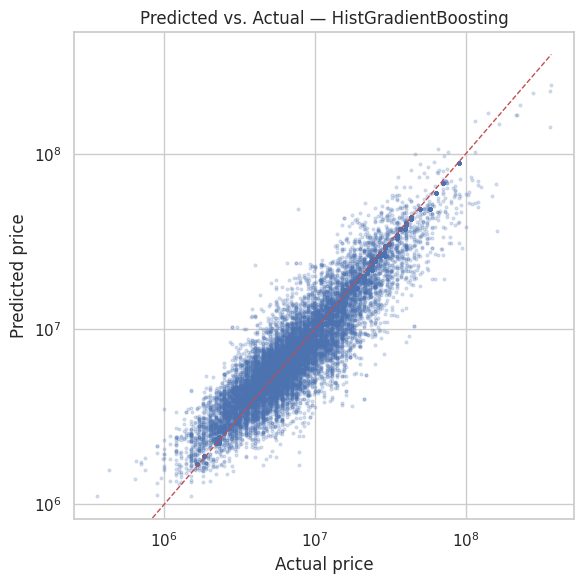

In [25]:
# Predicted vs. actual scatter plot for the winning model
best_pred = np.expm1(best_model.predict(X_test))
plt.figure(figsize=(6, 6))
plt.scatter(actual, best_pred, s=4, alpha=0.2)
lims = [0, max(actual.max(), best_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs. Actual — {best_name}")
plt.tight_layout()
plt.show()

**Model comparison & conclusion.** `LinearRegression` is fast but, being a
purely linear model with one-hot categoricals, it extrapolates badly on rare
combinations of large area / many bathrooms, producing occasional wildly-off
predictions and a poor R². `RandomForestRegressor`, even trained on a subsample,
captures non-linear interactions much better. `HistGradientBoostingRegressor`
trained on the full dataset gets the best R² and lowest error while also being by
far the fastest model to train (histogram-based boosting is very efficient even on
a single CPU core) — so **we export `HistGradientBoosting` as the production
model**.

In [26]:
# Bonus: quick 5-fold cross-validation of the winning pipeline on a subsample (for speed)
from sklearn.model_selection import cross_val_score

cv_sample = X_train.sample(n=min(20000, len(X_train)), random_state=1)
y_cv_sample = y_train.loc[cv_sample.index]
cv_scores = cross_val_score(best_model, cv_sample, y_cv_sample, cv=5, scoring="r2")
print("5-fold CV R2 scores:", cv_scores.round(3))
print("Mean CV R2:", cv_scores.mean().round(3))

5-fold CV R2 scores: [0.916 0.921 0.92  0.915 0.919]
Mean CV R2: 0.918


## 2.6 Export the Model

In [27]:
import joblib

joblib.dump(best_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction (INR):", np.expm1(loaded.predict(sample))[0])
print("Actual (INR):", np.expm1(y_test.iloc[0]))

Reloaded prediction (INR): 9864438.244771294
Actual (INR): 8099999.999999998


In [28]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Saved locations.json with", df["location_grouped"].nunique(), "locations")

Saved locations.json with 31 locations


In [29]:
import sklearn
print("scikit-learn version used for training:", sklearn.__version__)

scikit-learn version used for training: 1.8.0


**Version pinning note:** this pickle was produced with the scikit-learn
version printed above. The FastAPI backend's `requirements.txt` pins the same
version so the pipeline loads reliably.

### Final metrics for the exported model

In [30]:
final_row = comparison.loc[[best_name]]
final_row

,MAE,RMSE,R2,fit_seconds
HistGradientBoosting,1.350905e+06,3.786719e+06,0.905401,10.074028
